In [1]:
#for 16/12/25


import pandas as pd

df = pd.read_csv(
    "Run2_SI383820251216115009_PartStatistics_all.csv",
    sep="\t"
)

# 1) Extract timestamp part from JO_ID (after first 6 chars)
df["timestamp_str"] = df["JO_ID"].str.slice(6)

# 2) Parse to datetime (adjust format if needed)
df["base_timestamp"] = pd.to_datetime(
    df["timestamp_str"],
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

# 3) Use the first row's parsed timestamp as the start
start_time = df["base_timestamp"].iloc[0]

# Offset correction by 40 minutes and 24 seconds
offset = pd.Timedelta(minutes=14, seconds=47)
start_time_corrected = start_time + offset   # use + offset if this series is behind

# 4) Create a new timestamp with +1 second per row, from corrected start
df["Timestamp"] = start_time_corrected + pd.to_timedelta(df.index, unit="s")



In [2]:
# df has at least: 'timestamp' and 'LA_INDEX'

result = df[["Timestamp", "LA_INDEX"]]
result.to_csv("Timestamp_LA_INDEX_16.csv", index=False)


In [3]:
import sqlite3

db_path = "DoE_data.db"   # existing DB
table2_name = "la_index_data_16"  # new table name

conn = sqlite3.connect(db_path)

# Store DataFrame as new table (creates it if it doesn't exist)
result.to_sql(table2_name, conn, if_exists="replace", index=False)

conn.close()

In [4]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("DoE_data.db")

df1 = pd.read_sql_query(
    "SELECT Timestamp, Power_W FROM DoERun",
    conn,
    parse_dates=["Timestamp"]
)

df2 = pd.read_sql_query(
    "SELECT Timestamp, LA_INDEX FROM la_index_data_16",
    conn,
    parse_dates=["Timestamp"]
)

conn.close()

# Inner join on timestamp; use outer if you want all times from both
merged = pd.merge(df1, df2, on="Timestamp", how="inner")
merged.to_csv("16_12_Merged_Data_log_OT.csv", index=False)


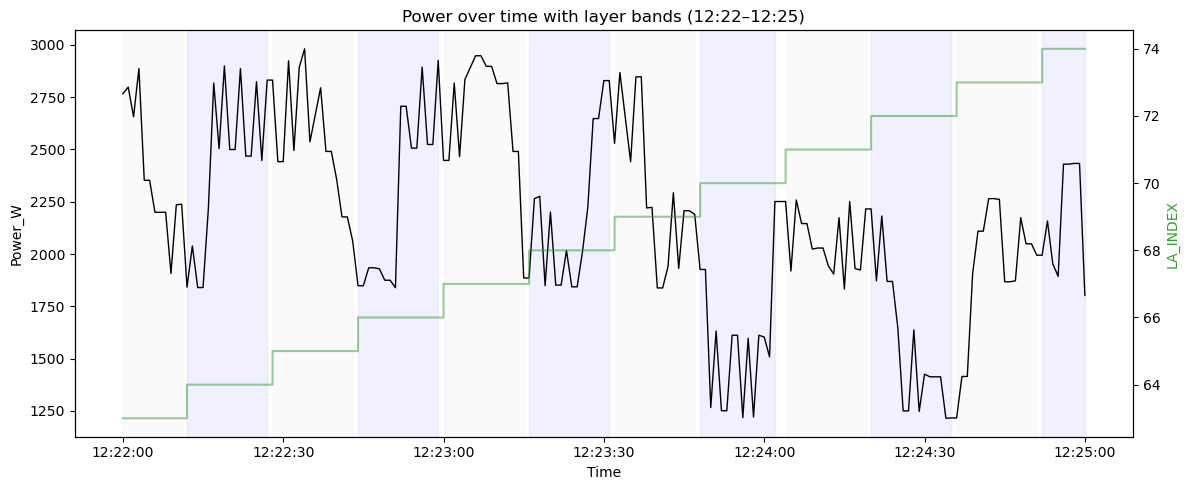

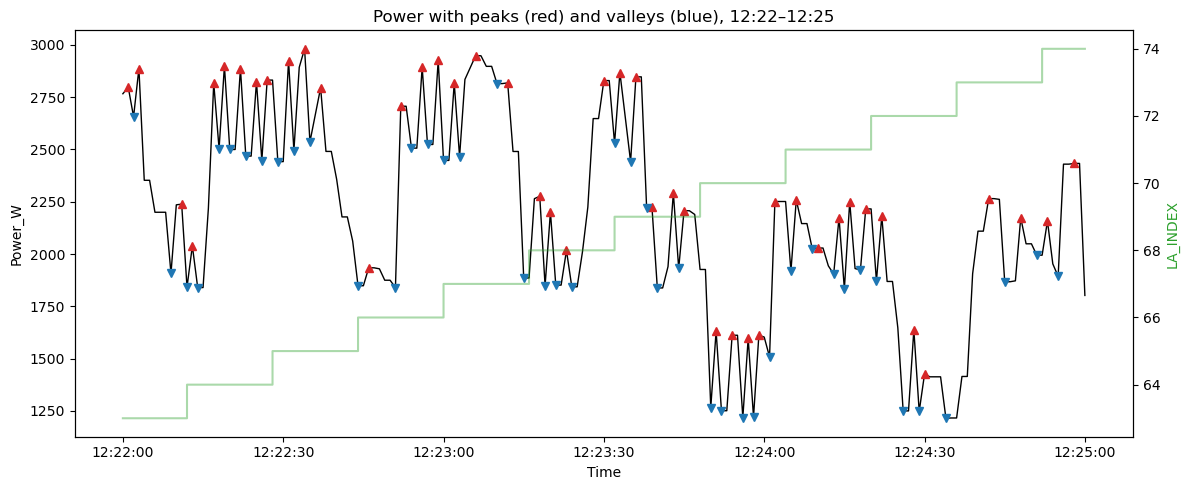

In [6]:

#16/12/25 from 12:08-12:12


import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --------------------------------------------------
# 1) Load data and ensure Timestamp / LA_INDEX / Power_W
# --------------------------------------------------

db_path = "DoE_data.db"
table_power = "DoERun"          # table with Power_W
table_la    = "la_index_data_16"  # table with LA_INDEX

conn = sqlite3.connect(db_path)

df_power = pd.read_sql_query(
    f"SELECT Timestamp, Power_W FROM {table_power}",
    conn,
    parse_dates=["Timestamp"]
)

df_la = pd.read_sql_query(
    f"SELECT Timestamp, LA_INDEX FROM {table_la}",
    conn,
    parse_dates=["Timestamp"]
)

conn.close()

# Merge on Timestamp
df = pd.merge(df_power, df_la, on="Timestamp", how="inner")
df = df.sort_values("Timestamp").reset_index(drop=True)

# --------------------------------------------------
# 2) Filter to 12:08-12:12 on 16/12/2025
# --------------------------------------------------

start = pd.Timestamp("2025-12-16 12:22:00")
end   = pd.Timestamp("2025-12-16 12:25:00")

df_win = df[(df["Timestamp"] >= start) & (df["Timestamp"] <= end)].copy()
df_win = df_win.sort_values("Timestamp").reset_index(drop=True)

# If the window is empty, you may want to check your timestamps or date.
# print(df_win.head(), df_win["Timestamp"].min(), df_win["Timestamp"].max())

# --------------------------------------------------
# 3) STEP / SEGMENT PLOT WITH LAYER BANDS (WINDOWED)
# --------------------------------------------------

fig1, ax1 = plt.subplots(figsize=(12, 5))

# Plot Power_W over time in window
ax1.plot(df_win["Timestamp"], df_win["Power_W"],
         color="black", linewidth=1.0, label="Power_W")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power_W")
ax1.set_title("Power over time with layer bands (12:22–12:25)")

# Compute time interval per LA_INDEX in window
layer_ranges = (
    df_win.groupby("LA_INDEX")["Timestamp"]
          .agg(["min", "max"])
          .reset_index()
)

# Draw vertical bands (one per layer) using alternating colors
colors = ["#f0f0f0", "#d0d0ff"]  # light gray and light blue
for i, row in layer_ranges.iterrows():
    t_min = row["min"]
    t_max = row["max"]
    ax1.axvspan(
        t_min, t_max,
        color=colors[i % len(colors)],
        alpha=0.3
    )

# Overlay LA_INDEX as a step function on a second y-axis
ax1b = ax1.twinx()
ax1b.step(df_win["Timestamp"], df_win["LA_INDEX"],
          where="post", color="tab:green", alpha=0.5)
ax1b.set_ylabel("LA_INDEX", color="tab:green")

fig1.tight_layout()

# --------------------------------------------------
# 4) VALLEY / PEAK MARKERS PER LAYER (WINDOWED)
# --------------------------------------------------

fig2, ax2 = plt.subplots(figsize=(12, 5))

# Power line
ax2.plot(df_win["Timestamp"], df_win["Power_W"],
         color="black", linewidth=1.0, label="Power_W")

# Find peaks (local maxima) and valleys (local minima) in window
# Tune these parameters for your signal if needed
peaks, _ = find_peaks(df_win["Power_W"])
valleys, _ = find_peaks(-df_win["Power_W"])

timestamps = df_win["Timestamp"].to_numpy()
power_vals = df_win["Power_W"].to_numpy()

# Plot peaks (triangles up)
for idx in peaks:
    ax2.plot(
        timestamps[idx],
        power_vals[idx],
        marker="^",
        color="tab:red",
        markersize=6
    )

# Plot valleys (triangles down)
for idx in valleys:
    ax2.plot(
        timestamps[idx],
        power_vals[idx],
        marker="v",
        color="tab:blue",
        markersize=6
    )

ax2.set_xlabel("Time")
ax2.set_ylabel("Power_W")
ax2.set_title("Power with peaks (red) and valleys (blue), 12:22–12:25")

# LA_INDEX step vs time on second axis
ax2b = ax2.twinx()
ax2b.step(df_win["Timestamp"], df_win["LA_INDEX"],
          where="post", color="tab:green", alpha=0.4)
ax2b.set_ylabel("LA_INDEX", color="tab:green")

fig2.tight_layout()




In [1]:
#for 15/12/25


import pandas as pd

df = pd.read_csv(
    "Run1_SI383820251215093822_PartStatistics_all.csv",
    sep="\t"
)

# 1) Extract timestamp part from JO_ID (after first 6 chars)
df["timestamp_str"] = df["JO_ID"].str.slice(6)

# 2) Parse to datetime (adjust format if needed)
df["base_timestamp"] = pd.to_datetime(
    df["timestamp_str"],
    format="%Y%m%d%H%M%S",
    errors="coerce"
)

# 3) Use the first row's parsed timestamp as the start
start_time = df["base_timestamp"].iloc[0]

# Offset correction by 40 minutes and 24 seconds
offset = pd.Timedelta(minutes=14, seconds=47)
start_time_corrected = start_time + offset   # use + offset if this series is behind

# 4) Create a new timestamp with +1 second per row, from corrected start
df["Timestamp"] = start_time_corrected + pd.to_timedelta(df.index, unit="s")



In [2]:
# df has at least: 'timestamp' and 'LA_INDEX'

result = df[["Timestamp", "LA_INDEX"]]
result.to_csv("Timestamp_LA_INDEX_15.csv", index=False)


In [3]:
import sqlite3

db_path = "DoE_data.db"   # existing DB
table2_name = "la_index_data_15"  # new table name

conn = sqlite3.connect(db_path)

# Store DataFrame as new table (creates it if it doesn't exist)
result.to_sql(table2_name, conn, if_exists="replace", index=False)

conn.close()

In [4]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("DoE_data.db")

df1 = pd.read_sql_query(
    "SELECT Timestamp, Power_W FROM DoERun",
    conn,
    parse_dates=["Timestamp"]
)

df2 = pd.read_sql_query(
    "SELECT Timestamp, LA_INDEX FROM la_index_data_15",
    conn,
    parse_dates=["Timestamp"]
)

conn.close()

# Inner join on timestamp; use outer if you want all times from both
merged = pd.merge(df1, df2, on="Timestamp", how="inner")
merged.to_csv("16_12_Merged_Data_log_OT.csv", index=False)


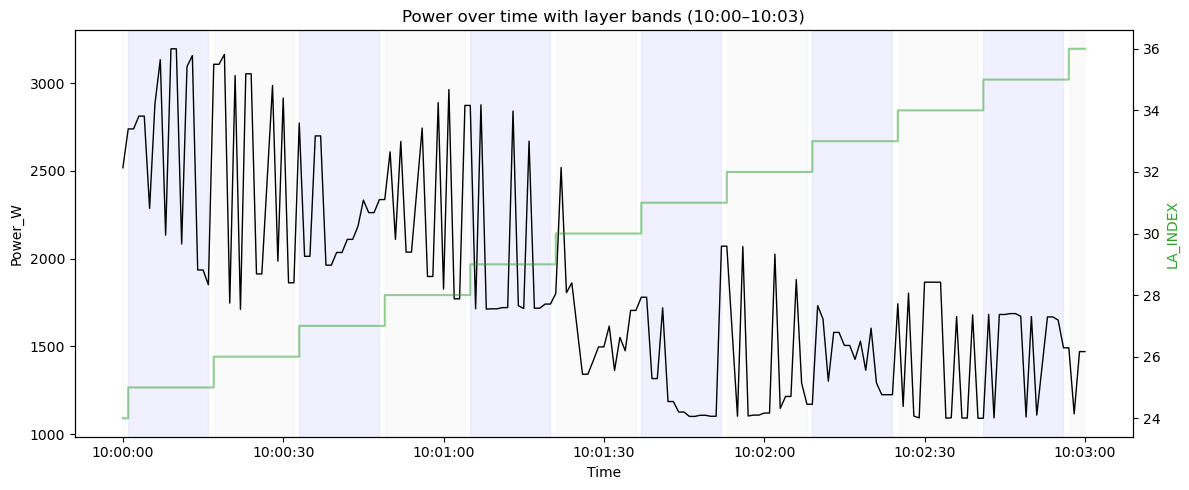

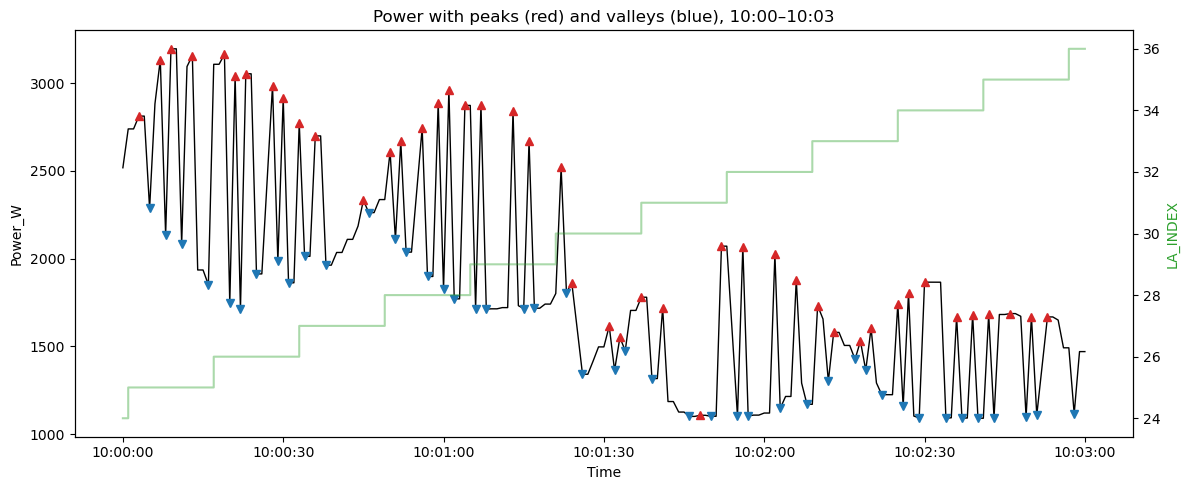

In [5]:

#15/12/25 from 10:00-10:03


import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --------------------------------------------------
# 1) Load data and ensure Timestamp / LA_INDEX / Power_W
# --------------------------------------------------

db_path = "DoE_data.db"
table_power = "DoERun"          # table with Power_W
table_la    = "la_index_data_15"  # table with LA_INDEX

conn = sqlite3.connect(db_path)

df_power = pd.read_sql_query(
    f"SELECT Timestamp, Power_W FROM {table_power}",
    conn,
    parse_dates=["Timestamp"]
)

df_la = pd.read_sql_query(
    f"SELECT Timestamp, LA_INDEX FROM {table_la}",
    conn,
    parse_dates=["Timestamp"]
)

conn.close()

# Merge on Timestamp
df = pd.merge(df_power, df_la, on="Timestamp", how="inner")
df = df.sort_values("Timestamp").reset_index(drop=True)

# --------------------------------------------------
# 2) Filter to 12:08-12:12 on 16/12/2025
# --------------------------------------------------

start = pd.Timestamp("2025-12-15 10:00:00")
end   = pd.Timestamp("2025-12-15 10:03:00")

df_win = df[(df["Timestamp"] >= start) & (df["Timestamp"] <= end)].copy()
df_win = df_win.sort_values("Timestamp").reset_index(drop=True)

# If the window is empty, you may want to check your timestamps or date.
# print(df_win.head(), df_win["Timestamp"].min(), df_win["Timestamp"].max())

# --------------------------------------------------
# 3) STEP / SEGMENT PLOT WITH LAYER BANDS (WINDOWED)
# --------------------------------------------------

fig1, ax1 = plt.subplots(figsize=(12, 5))

# Plot Power_W over time in window
ax1.plot(df_win["Timestamp"], df_win["Power_W"],
         color="black", linewidth=1.0, label="Power_W")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power_W")
ax1.set_title("Power over time with layer bands (10:00–10:03)")

# Compute time interval per LA_INDEX in window
layer_ranges = (
    df_win.groupby("LA_INDEX")["Timestamp"]
          .agg(["min", "max"])
          .reset_index()
)

# Draw vertical bands (one per layer) using alternating colors
colors = ["#f0f0f0", "#d0d0ff"]  # light gray and light blue
for i, row in layer_ranges.iterrows():
    t_min = row["min"]
    t_max = row["max"]
    ax1.axvspan(
        t_min, t_max,
        color=colors[i % len(colors)],
        alpha=0.3
    )

# Overlay LA_INDEX as a step function on a second y-axis
ax1b = ax1.twinx()
ax1b.step(df_win["Timestamp"], df_win["LA_INDEX"],
          where="post", color="tab:green", alpha=0.5)
ax1b.set_ylabel("LA_INDEX", color="tab:green")

fig1.tight_layout()

# --------------------------------------------------
# 4) VALLEY / PEAK MARKERS PER LAYER (WINDOWED)
# --------------------------------------------------

fig2, ax2 = plt.subplots(figsize=(12, 5))

# Power line
ax2.plot(df_win["Timestamp"], df_win["Power_W"],
         color="black", linewidth=1.0, label="Power_W")

# Find peaks (local maxima) and valleys (local minima) in window
# Tune these parameters for your signal if needed
peaks, _ = find_peaks(df_win["Power_W"])
valleys, _ = find_peaks(-df_win["Power_W"])

timestamps = df_win["Timestamp"].to_numpy()
power_vals = df_win["Power_W"].to_numpy()

# Plot peaks (triangles up)
for idx in peaks:
    ax2.plot(
        timestamps[idx],
        power_vals[idx],
        marker="^",
        color="tab:red",
        markersize=6
    )

# Plot valleys (triangles down)
for idx in valleys:
    ax2.plot(
        timestamps[idx],
        power_vals[idx],
        marker="v",
        color="tab:blue",
        markersize=6
    )

ax2.set_xlabel("Time")
ax2.set_ylabel("Power_W")
ax2.set_title("Power with peaks (red) and valleys (blue), 10:00–10:03")

# LA_INDEX step vs time on second axis
ax2b = ax2.twinx()
ax2b.step(df_win["Timestamp"], df_win["LA_INDEX"],
          where="post", color="tab:green", alpha=0.4)
ax2b.set_ylabel("LA_INDEX", color="tab:green")

fig2.tight_layout()


